# Installing and importing libraries

In [1]:
import pandas as pd
import numpy as np
import nltk
import re
import torch
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import tensorflow as tf
import tensorflow_hub as hub
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt

In [2]:
nltk.download('stopwords')
nltk.download('words')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dewim\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\dewim\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\words.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\dewim\AppData\Roaming\nltk_data...


True

In [3]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\dewim\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


True

In [4]:
stop_words = set(stopwords.words('english'))

# To check is there any GPU available or not

In [5]:
is_cuda = torch.cuda.is_available()

# If we have a GPU available, we'll set our device to GPU.
if is_cuda:
    device = torch.device("cuda")
    print("GPU is available")
else:
    device = torch.device("cpu")
    print("GPU not available, CPU used")


GPU not available, CPU used


# Load the Nike Review dataset for sentiment analysis between positive and negative reviews

In [98]:
df_nike_reviews2 = pd.read_csv('df_nike_reviews2.csv', sep=',', encoding='utf-8', engine='python', on_bad_lines='skip')
print(df_nike_reviews2.shape)

(103770, 15)


In [99]:
df_nike_reviews2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103770 entries, 0 to 103769
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   content                 103770 non-null  object 
 1   score                   103770 non-null  int64  
 2   thumbsUpCount           103770 non-null  int64  
 3   reviewCreatedVersion    96207 non-null   object 
 4   at                      103770 non-null  object 
 5   appVersion              96207 non-null   object 
 6   id                      103770 non-null  int64  
 7   sentiment_polarity      103770 non-null  float64
 8   sentiment_subjectivity  103770 non-null  float64
 9   sentiment_rating        103770 non-null  object 
 10  final_cleaned           103770 non-null  object 
 11  token                   103770 non-null  object 
 12  token_after_sr          103770 non-null  object 
 13  lemmatized_tokens       103770 non-null  object 
 14  cleaned_text        

In [100]:
df_nike_reviews2 = df_nike_reviews2.dropna(subset=['cleaned_text'])

In [101]:
df_nike_reviews2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 103226 entries, 0 to 103769
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   content                 103226 non-null  object 
 1   score                   103226 non-null  int64  
 2   thumbsUpCount           103226 non-null  int64  
 3   reviewCreatedVersion    95725 non-null   object 
 4   at                      103226 non-null  object 
 5   appVersion              95725 non-null   object 
 6   id                      103226 non-null  int64  
 7   sentiment_polarity      103226 non-null  float64
 8   sentiment_subjectivity  103226 non-null  float64
 9   sentiment_rating        103226 non-null  object 
 10  final_cleaned           103226 non-null  object 
 11  token                   103226 non-null  object 
 12  token_after_sr          103226 non-null  object 
 13  lemmatized_tokens       103226 non-null  object 
 14  cleaned_text            1

In [102]:
df_nike_reviews2.head()

,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion,id,sentiment_polarity,sentiment_subjectivity,sentiment_rating,final_cleaned,token,token_after_sr,lemmatized_tokens,cleaned_text
0,i love the guided runs and use their programs ...,3,1,4.64.0,2025-03-25 14:04:23,4.64.0,1,0.016667,0.462821,Neutral,i love the guided runs and use their programs ...,"['i', 'love', 'the', 'guided', 'runs', 'and', ...","['love', 'guided', 'programs', 'regular', 'rou...","['love', 'guided', 'program', 'regular', 'rout...",love guided program regular routine week get s...
1,the nike run club is the best the app tracks p...,5,0,4.64.0,2025-03-25 00:54:56,4.64.0,3,1.000000,0.300000,Positive,the nike run club is the best the app tracks p...,"['the', 'nike', 'run', 'club', 'is', 'the', 'b...","['club', 'best', 'tracks', 'progress', 'graphi...","['club', 'best', 'track', 'progress', 'graphic...",club best track progress graphically geographi...
2,this app has various guided training options t...,5,0,4.64.0,2025-03-25 00:52:34,4.64.0,4,0.000000,0.500000,Positive,this app has various guided training options t...,"['this', 'app', 'has', 'various', 'guided', 't...","['various', 'guided', 'options', 'help', 'runn...","['various', 'guided', 'option', 'help', 'runne...",various guided option help runner train goal w...
3,i like everything the app has to offer from gu...,2,1,4.64.0,2025-03-25 00:42:15,4.64.0,5,0.000000,0.333333,Negative,i like everything the app has to offer from gu...,"['i', 'like', 'everything', 'the', 'app', 'has...","['everything', 'offer', 'guidance', 'challenge...","['everything', 'offer', 'guidance', 'challenge...",everything offer guidance challenge constantly...
4,easy to use beginner friendly i am not a bot,5,0,4.64.0,2025-03-24 18:01:49,4.64.0,6,0.404167,0.666667,Positive,easy to use beginner friendly i am nota bot,"['easy', 'to', 'use', 'beginner', 'friendly', ...","['easy', 'beginner', 'friendly', 'nota', 'bot']","['easy', 'beginner', 'friendly', 'nota', 'bot']",easy beginner friendly nota bot


In [103]:
# Hapus kolom yang tidak dibutuhkan
df_nike_reviews2 = df_nike_reviews2[['cleaned_text', 'sentiment_rating']]

# Rename kolom sesuai keinginan
df_nike_reviews2 = df_nike_reviews2.rename(columns={'cleaned_text': 'review', 'sentiment_rating': 'sentiment'})

# Cek hasilnya
print(df_nike_reviews2.head())


                                              review sentiment
0  love guided program regular routine week get s...   Neutral
1  club best track progress graphically geographi...  Positive
2  various guided option help runner train goal w...  Positive
3  everything offer guidance challenge constantly...  Negative
4                    easy beginner friendly nota bot  Positive


In [104]:
df_nike_reviews2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 103226 entries, 0 to 103769
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   review     103226 non-null  object
 1   sentiment  103226 non-null  object
dtypes: object(2)
memory usage: 2.4+ MB


# Exploratory Data Analysis for IMDB dataset

In [106]:
class EDA():
    def get_length_dist(self, data):
        rev_len = [len(i) for i in data]
        pd.Series(rev_len).hist(bins=30, color='skyblue', edgecolor='black')
        plt.title('Distribusi Panjang Komentar')
        plt.xlabel('Panjang Komentar')
        plt.ylabel('Jumlah Komentar')
        plt.grid(axis='y', linestyle='--')
        plt.show()
        print(pd.Series(rev_len).describe())
    
    def get_class_dist(self, df):
        # Kalau sudah string, langsung value_counts()
        df['sentiment'].value_counts().plot(kind='bar', color=['red', 'orange', 'green'], figsize=(7, 4))
        plt.title('Distribusi Sentimen Komentar')
        plt.xlabel('Jenis Sentimen')
        plt.ylabel('Jumlah Komentar')
        plt.grid(axis='y', linestyle='--')
        plt.show()


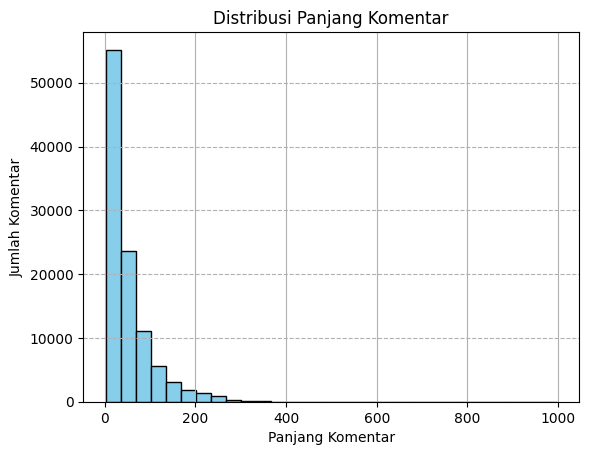

count    103226.000000
mean         49.799237
std          53.097077
min           2.000000
25%          14.000000
50%          32.000000
75%          66.000000
max         997.000000
dtype: float64


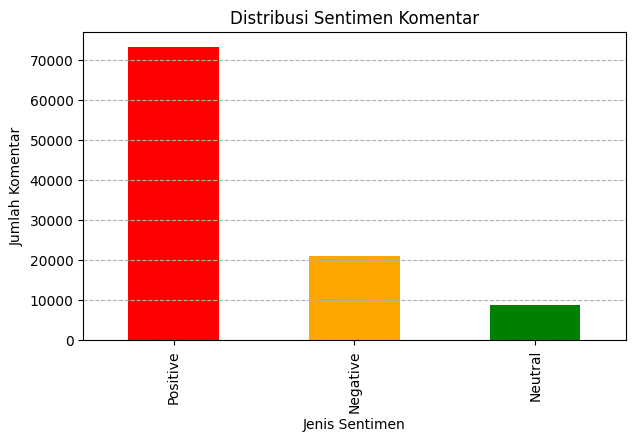

In [107]:
eda = EDA()
eda.get_length_dist(df_nike_reviews2['review'])
eda.get_class_dist(df_nike_reviews2)

# Preprocess the data

In [108]:
def preprocess_text(text):
    # Menghapus tag HTML jika ada
    text = re.sub(r'<[^>]*>', '', text)

    # Menghapus karakter non-alfanumerik dan spasi ekstra
    text = re.sub(r'[^\w\s]', '', text)  # Tetap menyimpan angka (digit)
    text = re.sub(r'\s+', ' ', text).strip()  # Menghapus spasi berlebih

    # Mengubah teks menjadi huruf kecil
    text = text.lower()

    # Tokenisasi dan menghapus stopwords
    words = word_tokenize(text)
    words = [word for word in words if word not in stop_words]

    # Menggabungkan kembali menjadi string yang bersih
    return ' '.join(words)

In [109]:
import nltk
nltk.download('punkt')       
nltk.download('punkt_tab')   

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\dewim\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\dewim\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [110]:
# Terapkan preprocessing pada kolom 'review'
df_nike_reviews2['review'] = df_nike_reviews2['review'].apply(preprocess_text)

In [111]:
df_nike_reviews2['review'].head(20)

0     love guided program regular routine week get s...
1     club best track progress graphically geographi...
2     various guided option help runner train goal w...
3     everything offer guidance challenge constantly...
4                       easy beginner friendly nota bot
5     nothave first half marathon goal without help ...
6                          step good fitness motivation
7     great recently however constant issue freezing...
8     helpful beginner runner struggling find plan p...
9     edit log often log deleted saved downloaded en...
10                                              offline
11    love guided travelled significantly pm gamin w...
12    since become sluggish inaccurate crash day not...
13    enjoy coaching disappointed notlogged properly...
14    train marathon coach lovely people guided full...
15      inspiring fun help maintaining focus joy listen
16                epic race wisdom joy huge thanks team
17          love fact track without internet con

# Split x=feature, y=target

In [18]:
x = df_nike_reviews2['review']
y = df_nike_reviews2['sentiment']

In [112]:
from sklearn.preprocessing import LabelEncoder
label_encode = LabelEncoder()
Y = label_encode.fit_transform(y)
print("Label hasil encoding:", Y[:10])  # Cek hasil encoding untuk 10 data pertama
print("Mapping Label Encoding:", dict(zip(label_encode.classes_, range(len(label_encode.classes_)))))

Label hasil encoding: [1 2 2 0 2 2 2 0 2 2]
Mapping Label Encoding: {'Negative': 0, 'Neutral': 1, 'Positive': 2}


In [113]:
y

0          Neutral
1         Positive
2         Positive
3         Negative
4         Positive
            ...   
103765    Positive
103766    Positive
103767    Positive
103768    Positive
103769    Positive
Name: sentiment, Length: 103226, dtype: object

# Split the dataset into training and testing sets

In [114]:
xtrain, xtest, ytrain, ytest = train_test_split(x, Y, test_size=0.2, random_state=42)

# Create a vocabulary

In [115]:
# Create a vocabulary
from collections import Counter
word_counts = Counter(' '.join(xtrain).split())

# Display each word in the vocabulary along with its count

In [116]:
for word, count in word_counts.items():
    print(f"{word}: {count}")

love: 12243
widget: 202
take: 1030
thanks: 1169
marathon: 1211
planner: 15
recently: 657
changed: 376
right: 743
almost: 597
speed: 1069
long: 977
thought: 268
normal: 80
final: 33
week: 1541
consist: 2
less: 426
pm: 1934
remember: 77
short: 158
recovery: 58
notlogin: 158
account: 908
give: 2217
error: 959
month: 1484
son: 16
turned: 176
onto: 54
everything: 1628
expecting: 18
enhancement: 19
old: 1152
version: 2113
complete: 482
revamp: 9
dumb: 26
release: 68
regret: 16
upgrade: 269
unfortunate: 25
choose: 243
tracker: 561
better: 2908
map: 1456
track: 1228
perfectly: 374
force: 505
close: 606
notuse: 404
scheduler: 4
crash: 1682
sure: 344
fixed: 772
fine: 776
great: 16706
motivator: 283
quite: 400
good: 8744
apps: 2735
except: 295
past: 692
couple: 494
notseem: 224
updating: 221
friend: 2943
accurately: 477
phone: 2947
example: 193
sometimes: 2214
wednesday: 7
thursday: 4
showing: 388
new: 3054
weekly: 162
show: 1373
last: 1960
ended: 111
previous: 793
withe: 4
ranked: 4
someone: 292

In [117]:
vocab = [word for word, count in word_counts.most_common()]
vocab

['great',
 'love',
 'good',
 'best',
 'gas',
 'easy',
 'need',
 'help',
 'coach',
 'feature',
 'new',
 'awesome',
 'year',
 'guided',
 'phone',
 'friend',
 'plan',
 'better',
 'apps',
 'workout',
 'accurate',
 'challenge',
 'well',
 'make',
 'time',
 'issue',
 'way',
 'nice',
 'stop',
 'music',
 'android',
 'pace',
 'give',
 'sometimes',
 'since',
 'version',
 'start',
 'data',
 'day',
 'last',
 'star',
 'go',
 'pm',
 'want',
 'record',
 'see',
 'motivated',
 'problem',
 'runner',
 'watch',
 'progress',
 'wish',
 'far',
 'option',
 'first',
 'crash',
 'amazing',
 'log',
 'everything',
 'mile',
 'activity',
 'add',
 'ran',
 'week',
 'say',
 'month',
 'map',
 'pause',
 'bug',
 'free',
 'try',
 'tried',
 'going',
 'show',
 'perfect',
 'goal',
 'helpful',
 'motivation',
 'notwork',
 'lost',
 'end',
 'user',
 'working',
 'though',
 'without',
 'able',
 'started',
 'track',
 'marathon',
 'useful',
 'thanks',
 'old',
 'got',
 'route',
 'coaching',
 'half',
 'application',
 'overall',
 'progra

# Classification with various classifiers
1. Linear SVM
2. Logistic Regression (LR)
3. Naive Bayes
4. XGBoost
5. Random Forest


In [118]:
#Import libraries
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from timeit import default_timer as timer

## Initialize classifiers

In [119]:
svm_classifier = LinearSVC()
logistic_regression = LogisticRegression(max_iter=1000)
nb_classifier = MultinomialNB()
xgboost_classifier = XGBClassifier()
random_forest_classifier = RandomForestClassifier(n_estimators=100, max_depth=3, max_features='sqrt', min_samples_leaf=4, bootstrap=True, n_jobs=-1, random_state=42)


In [120]:
def evaluate_model(model, xtest, ytest):
    # Prediksi dengan model
    y_pred = model.predict(xtest)

    # Evaluasi hasil prediksi
    accuracy = accuracy_score(ytest, y_pred)
    precision = precision_score(ytest, y_pred, average='weighted')  # Pakai average='weighted' untuk multiclass
    recall = recall_score(ytest, y_pred, average='weighted')
    f1 = f1_score(ytest, y_pred, average='weighted')

    # Laporan klasifikasi dan matriks kebingungan
    report = classification_report(ytest, y_pred, target_names=['Negative', 'Neutral', 'Positive'])
    cm = confusion_matrix(ytest, y_pred)

    return y_pred, accuracy, precision, recall, f1, report, cm

In [121]:
# Define batch size
batch_size = 1000

# 1. TF-IDF

## TF-IDF Vectorization

In [122]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

In [123]:
tfidf_vectorizer.fit(xtrain)

TfidfVectorizer(max_features=5000)

### Process the data in smaller batches for training data

In [124]:
start = timer()
tfidf_vectorizer_xtrain = np.vstack([
    tfidf_vectorizer.transform(xtrain[i:i + batch_size]).toarray()  # Batching dengan ukuran batch_size
    for i in range(0, len(xtrain), batch_size)
])
print('Waktu yang dibutuhkan untuk embedding TF-IDF pada data train:', timer() - start)

Waktu yang dibutuhkan untuk embedding TF-IDF pada data train: 41.23668870000074


### Repeat the same process for test data

In [125]:
# Embedding TF-IDF untuk data test dengan batching
start = timer()
tfidf_vectorizer_xtest = np.vstack([
    tfidf_vectorizer.transform(xtest[i:i + batch_size]).toarray()  # Batching dengan ukuran batch_size
    for i in range(0, len(xtest), batch_size)
])
print('Waktu yang dibutuhkan untuk embedding TF-IDF pada data test:', timer() - start)

Waktu yang dibutuhkan untuk embedding TF-IDF pada data test: 1.7211158000009164


## Fit classifiers

In [127]:
print(type(tfidf_vectorizer_xtrain))  # Harusnya <class 'numpy.ndarray'>
print(tfidf_vectorizer_xtrain.shape)

print(type(tfidf_vectorizer_xtest))  # Harusnya <class 'numpy.ndarray'>
print(tfidf_vectorizer_xtest.shape)


<class 'numpy.ndarray'>
(82580, 5000)
<class 'numpy.ndarray'>
(20646, 5000)


In [128]:
# Training model dan mengukur waktu yang dibutuhkan
start = timer()
svm_tfidf = svm_classifier.fit(tfidf_vectorizer_xtrain, ytrain)
print('Required time for training Linear SVM classifier:', timer() - start)

start = timer()
lr_tfidf = logistic_regression.fit(tfidf_vectorizer_xtrain, ytrain)
print('Required time for training Logistic Regression classifier:', timer() - start)

start = timer()
nb_tfidf = nb_classifier.fit(tfidf_vectorizer_xtrain, ytrain)
print('Required time for training Naive Bayes classifier:', timer() - start)

start = timer()
xgboost_tfidf = xgboost_classifier.fit(tfidf_vectorizer_xtrain, ytrain)
print('Required time for training XGBoost classifier:', timer() - start)

start = timer()
rfc_tfidf = random_forest_classifier.fit(tfidf_vectorizer_xtrain, ytrain)
print('Required time for training Random Forest classifier:', timer() - start)

Required time for training Linear SVM classifier: 21.30303020000065
Required time for training Logistic Regression classifier: 261.5995946000003
Required time for training Naive Bayes classifier: 2.382953800000905
Required time for training XGBoost classifier: 420.13500190000013
Required time for training Random Forest classifier: 35.7313993000007


## Linear SVM

In [129]:
start = timer()
y_pred_svm, accuracy_svm, precision_svm, recall_svm, f1_svm, report_svm, confusion_matrix_svm = evaluate_model(svm_tfidf, tfidf_vectorizer_xtest, ytest)
print('Waktu prediksi SVM:', timer() - start)

Waktu prediksi SVM: 1.2153567000004841


### Print actual vs. predicted results for LinearSVM

In [130]:
# Menampilkan label kelas unik pada data testing
print("=== Label Kelas yang Ada ===")
print(set(ytest))

# Menampilkan contoh hasil prediksi SVM (15 data pertama)
print("\nContoh 15 hasil prediksi SVM:")
for actual, predicted in zip(ytest[:15], y_pred_svm[:15]):
    print(f"Actual: {actual}, SVM Predicted: {predicted}")

=== Label Kelas yang Ada ===
{np.int64(0), np.int64(1), np.int64(2)}

Contoh 15 hasil prediksi SVM:
Actual: 0, SVM Predicted: 2
Actual: 2, SVM Predicted: 2
Actual: 2, SVM Predicted: 2
Actual: 2, SVM Predicted: 2
Actual: 2, SVM Predicted: 2
Actual: 0, SVM Predicted: 0
Actual: 2, SVM Predicted: 2
Actual: 2, SVM Predicted: 2
Actual: 2, SVM Predicted: 2
Actual: 0, SVM Predicted: 0
Actual: 2, SVM Predicted: 2
Actual: 2, SVM Predicted: 2
Actual: 2, SVM Predicted: 2
Actual: 2, SVM Predicted: 2
Actual: 2, SVM Predicted: 2


In [131]:
# Menampilkan hasil evaluasi
print("\n=== Evaluasi SVM ===")
print(f"Accuracy SVM: {accuracy_svm:.4f}")
print(f"Precision SVM: {precision_svm:.4f}")
print(f"Recall SVM: {recall_svm:.4f}")
print(f"F1 Score SVM: {f1_svm:.4f}")

print("\n=== Classification Report SVM ===")
print(report_svm)

print("\n=== Confusion Matrix SVM ===")
print(confusion_matrix_svm)


=== Evaluasi SVM ===
Accuracy SVM: 0.8399
Precision SVM: 0.8049
Recall SVM: 0.8399
F1 Score SVM: 0.8132

=== Classification Report SVM ===
              precision    recall  f1-score   support

    Negative       0.70      0.78      0.74      4124
     Neutral       0.34      0.06      0.11      1794
    Positive       0.89      0.95      0.92     14728

    accuracy                           0.84     20646
   macro avg       0.64      0.60      0.59     20646
weighted avg       0.80      0.84      0.81     20646


=== Confusion Matrix SVM ===
[[ 3217   100   807]
 [  772   113   909]
 [  594   124 14010]]


## Logistic Regression

In [132]:
start = timer()
y_pred_lr, accuracy_lr, precision_lr, recall_lr, f1_lr, report_lr, cm_lr = evaluate_model(logistic_regression, tfidf_vectorizer_xtest, ytest)
print('Required time for Logistic Regression prediction:', timer() - start)

Required time for Logistic Regression prediction: 0.5604760999995051


### Print actual vs. predicted results for Logistic Regression

In [133]:
print("\n=== Contoh Prediksi Logistic Regression ===")
print("Label Kelas:", set(ytest))  # Menampilkan label kelas unik dari ytest
for actual, predicted in zip(ytest[:15], y_pred_lr[:15]):
    print(f"Actual: {actual}, Logistic Regression Predicted: {predicted}")


=== Contoh Prediksi Logistic Regression ===
Label Kelas: {np.int64(0), np.int64(1), np.int64(2)}
Actual: 0, Logistic Regression Predicted: 2
Actual: 2, Logistic Regression Predicted: 2
Actual: 2, Logistic Regression Predicted: 2
Actual: 2, Logistic Regression Predicted: 2
Actual: 2, Logistic Regression Predicted: 2
Actual: 0, Logistic Regression Predicted: 0
Actual: 2, Logistic Regression Predicted: 2
Actual: 2, Logistic Regression Predicted: 2
Actual: 2, Logistic Regression Predicted: 2
Actual: 0, Logistic Regression Predicted: 0
Actual: 2, Logistic Regression Predicted: 2
Actual: 2, Logistic Regression Predicted: 2
Actual: 2, Logistic Regression Predicted: 2
Actual: 2, Logistic Regression Predicted: 2
Actual: 2, Logistic Regression Predicted: 2


In [134]:
print("\n=== Evaluasi Logistic Regression ===")
print(f"Accuracy: {accuracy_lr:.4f}")
print(f"Precision (weighted): {precision_lr:.4f}")  # Menggunakan 'weighted' untuk multi-class
print(f"Recall (weighted): {recall_lr:.4f}")
print(f"F1-Score (weighted): {f1_lr:.4f}")
print("\nClassification Report:\n", report_lr)
print("Confusion Matrix:\n", cm_lr)


=== Evaluasi Logistic Regression ===
Accuracy: 0.8411
Precision (weighted): 0.8061
Recall (weighted): 0.8411
F1-Score (weighted): 0.8153

Classification Report:
               precision    recall  f1-score   support

    Negative       0.71      0.78      0.75      4124
     Neutral       0.33      0.07      0.12      1794
    Positive       0.89      0.95      0.92     14728

    accuracy                           0.84     20646
   macro avg       0.64      0.60      0.59     20646
weighted avg       0.81      0.84      0.82     20646

Confusion Matrix:
 [[ 3212   109   803]
 [  735   127   932]
 [  551   150 14027]]


## Naive bayes

In [135]:
start = timer()
y_pred_nb, accuracy_nb, precision_nb, recall_nb, f1_nb, report_nb, cm_nb = evaluate_model(nb_classifier, tfidf_vectorizer_xtest, ytest)
print('Required time for Naive Bayes prediction:', timer() - start)

Required time for Naive Bayes prediction: 0.5709808000010526


In [136]:
print("\n=== Contoh Prediksi Naive Bayes ===")
print("Label Kelas:", set(ytest))  # Menampilkan label kelas unik dari ytest
for actual, predicted in zip(ytest[:15], y_pred_nb[:15]):
    print(f"Actual: {actual}, Naive Bayes Predicted: {predicted}")


=== Contoh Prediksi Naive Bayes ===
Label Kelas: {np.int64(0), np.int64(1), np.int64(2)}
Actual: 0, Naive Bayes Predicted: 2
Actual: 2, Naive Bayes Predicted: 2
Actual: 2, Naive Bayes Predicted: 2
Actual: 2, Naive Bayes Predicted: 2
Actual: 2, Naive Bayes Predicted: 2
Actual: 0, Naive Bayes Predicted: 0
Actual: 2, Naive Bayes Predicted: 2
Actual: 2, Naive Bayes Predicted: 2
Actual: 2, Naive Bayes Predicted: 2
Actual: 0, Naive Bayes Predicted: 0
Actual: 2, Naive Bayes Predicted: 2
Actual: 2, Naive Bayes Predicted: 2
Actual: 2, Naive Bayes Predicted: 2
Actual: 2, Naive Bayes Predicted: 2
Actual: 2, Naive Bayes Predicted: 2


In [137]:
print("\n=== Evaluasi Naive Bayes ===")
print(f"Accuracy: {accuracy_nb:.4f}")
print(f"Precision (weighted): {precision_nb:.4f}")  # Menggunakan 'weighted' karena multiclass
print(f"Recall (weighted): {recall_nb:.4f}")
print(f"F1-Score (weighted): {f1_nb:.4f}")
print("\nClassification Report:\n", report_nb)
print("Confusion Matrix:\n", cm_nb)


=== Evaluasi Naive Bayes ===
Accuracy: 0.8349
Precision (weighted): 0.7932
Recall (weighted): 0.8349
F1-Score (weighted): 0.7994

Classification Report:
               precision    recall  f1-score   support

    Negative       0.69      0.76      0.72      4124
     Neutral       0.34      0.01      0.02      1794
    Positive       0.88      0.96      0.91     14728

    accuracy                           0.83     20646
   macro avg       0.64      0.58      0.55     20646
weighted avg       0.79      0.83      0.80     20646

Confusion Matrix:
 [[ 3121    20   983]
 [  767    23  1004]
 [  610    25 14093]]


## XGBoost Classifier

In [138]:
start = timer()
y_pred_xgboost, accuracy_xgboost, precision_xgboost, recall_xgboost, f1_xgboost, report_xgboost, cm_xgboost = evaluate_model(xgboost_classifier, tfidf_vectorizer_xtest, ytest)
print('Required time for XGBoost classifier prediction:', timer() - start)

Required time for XGBoost classifier prediction: 0.4813794000001508


### Print actual vs. predicted results for XGBoost classifier

In [139]:
print("\n=== Contoh Prediksi XGBoost ===")
print("Label Kelas:", set(ytest))  # Menampilkan label kelas unik dari ytest
for actual, predicted in zip(ytest[:15], y_pred_xgboost[:15]):
    print(f"Actual: {actual}, XGBoost Predicted: {predicted}")


=== Contoh Prediksi XGBoost ===
Label Kelas: {np.int64(0), np.int64(1), np.int64(2)}
Actual: 0, XGBoost Predicted: 2
Actual: 2, XGBoost Predicted: 2
Actual: 2, XGBoost Predicted: 2
Actual: 2, XGBoost Predicted: 2
Actual: 2, XGBoost Predicted: 2
Actual: 0, XGBoost Predicted: 0
Actual: 2, XGBoost Predicted: 2
Actual: 2, XGBoost Predicted: 2
Actual: 2, XGBoost Predicted: 2
Actual: 0, XGBoost Predicted: 2
Actual: 2, XGBoost Predicted: 2
Actual: 2, XGBoost Predicted: 2
Actual: 2, XGBoost Predicted: 2
Actual: 2, XGBoost Predicted: 2
Actual: 2, XGBoost Predicted: 2


In [140]:
print("\n=== Evaluasi XGBoost ===")
print(f"Accuracy: {accuracy_xgboost:.4f}")
print(f"Precision (weighted): {precision_xgboost:.4f}")  # Menggunakan 'weighted' karena multiclass
print(f"Recall (weighted): {recall_xgboost:.4f}")
print(f"F1-Score (weighted): {f1_xgboost:.4f}")
print("\nClassification Report:\n", report_xgboost)
print("Confusion Matrix:\n", cm_xgboost)


=== Evaluasi XGBoost ===
Accuracy: 0.8197
Precision (weighted): 0.7779
Recall (weighted): 0.8197
F1-Score (weighted): 0.7848

Classification Report:
               precision    recall  f1-score   support

    Negative       0.72      0.64      0.68      4124
     Neutral       0.34      0.04      0.07      1794
    Positive       0.85      0.97      0.90     14728

    accuracy                           0.82     20646
   macro avg       0.64      0.55      0.55     20646
weighted avg       0.78      0.82      0.78     20646

Confusion Matrix:
 [[ 2644    62  1418]
 [  571    66  1157]
 [  451    64 14213]]


## Random Forest Classifier

In [141]:
start = timer()
y_pred_rfc, accuracy_rfc, precision_rfc, recall_rfc, f1_rfc, report_rfc, cm_rfc = evaluate_model(random_forest_classifier, tfidf_vectorizer_xtest, ytest)
print('Required time for Random Forest classifier prediction: ', timer() - start)

Required time for Random Forest classifier prediction:  0.6013404999994236


d:\Rani\NLP (B) 2025\SentimentAnalysis\env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Rani\NLP (B) 2025\SentimentAnalysis\env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Rani\NLP (B) 2025\SentimentAnalysis\env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

### Print actual vs. predicted results for Random Forest classifier

In [142]:
print("\n=== Contoh Prediksi Random Forest ===")
print("Label Kelas:", set(ytest))  # Menampilkan label kelas unik dari ytest
for actual, predicted in zip(ytest[:15], y_pred_rfc[:15]):
    print(f"Actual: {actual}, Random Forest Predicted: {predicted}")


=== Contoh Prediksi Random Forest ===
Label Kelas: {np.int64(0), np.int64(1), np.int64(2)}
Actual: 0, Random Forest Predicted: 2
Actual: 2, Random Forest Predicted: 2
Actual: 2, Random Forest Predicted: 2
Actual: 2, Random Forest Predicted: 2
Actual: 2, Random Forest Predicted: 2
Actual: 0, Random Forest Predicted: 2
Actual: 2, Random Forest Predicted: 2
Actual: 2, Random Forest Predicted: 2
Actual: 2, Random Forest Predicted: 2
Actual: 0, Random Forest Predicted: 2
Actual: 2, Random Forest Predicted: 2
Actual: 2, Random Forest Predicted: 2
Actual: 2, Random Forest Predicted: 2
Actual: 2, Random Forest Predicted: 2
Actual: 2, Random Forest Predicted: 2


In [143]:
print("\n=== Evaluasi Random Forest ===")
print(f"Accuracy: {accuracy_rfc:.4f}")
print(f"Precision (weighted): {precision_rfc:.4f}")  # Menggunakan 'weighted' karena multiclass
print(f"Recall (weighted): {recall_rfc:.4f}")
print(f"F1-Score (weighted): {f1_rfc:.4f}")
print("\nClassification Report:\n", report_rfc)
print("Confusion Matrix:\n", cm_rfc)


=== Evaluasi Random Forest ===
Accuracy: 0.7134
Precision (weighted): 0.5089
Recall (weighted): 0.7134
F1-Score (weighted): 0.5940

Classification Report:
               precision    recall  f1-score   support

    Negative       0.00      0.00      0.00      4124
     Neutral       0.00      0.00      0.00      1794
    Positive       0.71      1.00      0.83     14728

    accuracy                           0.71     20646
   macro avg       0.24      0.33      0.28     20646
weighted avg       0.51      0.71      0.59     20646

Confusion Matrix:
 [[    0     0  4124]
 [    0     0  1794]
 [    0     0 14728]]


## Display all five models accuracy

In [144]:
model_names = ['SVM', 'Logistic Regression', 'Naive Bayes', 'XGBoost', 'Random Forest']
model_accuracies = [accuracy_svm, accuracy_lr, accuracy_nb, accuracy_xgboost, accuracy_rfc]

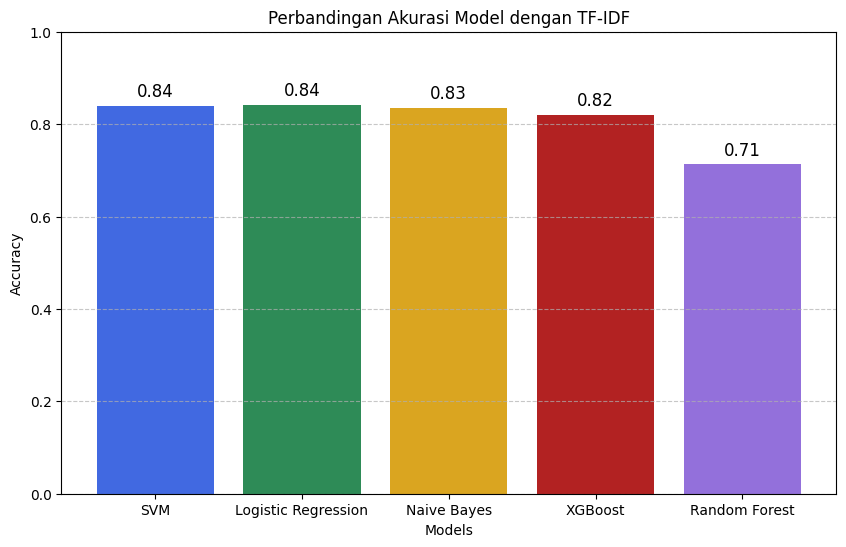

In [145]:
plt.figure(figsize=(10, 6))
plt.bar(model_names, model_accuracies, color=['royalblue', 'seagreen', 'goldenrod', 'firebrick', 'mediumpurple'])
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Perbandingan Akurasi Model dengan TF-IDF")
plt.ylim(0.0, 1.0)  # Set y-axis from 0 to 1 (100%)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Menampilkan nilai akurasi pada setiap batang
for i, acc in enumerate(model_accuracies):
    plt.text(i, acc + 0.02, f"{acc:.2f}", ha='center', color='black', fontsize=12)

# Menampilkan plot
plt.show()

# Universal Sentence Encoder (USE)
1. Linear SVM
2. Logistic Regression
3. XGBoost classifier
4. Random Forest classifier

## Load the Universal Sentence Encoder model, and embed this model

In [146]:
start = timer()
use_embed = hub.load("https://tfhub.dev/google/universal-sentence-encoder/4")
print('Required time for loading Universal Sentence Encoder (USE) from TensorFlow Hub:', timer() - start)


Required time for loading Universal Sentence Encoder (USE) from TensorFlow Hub: 11.208211699999083


In [147]:
xtrain_use = []
xtest_use = []

In [148]:
start = timer()
for i in range(0, len(xtrain), batch_size):
    batch_xtrain = xtrain[i:i + batch_size]
    batch_xtrain_use = np.array(use_embed(batch_xtrain))
    xtrain_use.extend(batch_xtrain_use)
print('Required time for embedding xtrain with Universal Sentence Encoder (USE):', timer() - start)

Required time for embedding xtrain with Universal Sentence Encoder (USE): 10.590603500000725


In [149]:
start = timer()
for i in range(0, len(xtest), batch_size):
    batch_xtest = xtest[i:i + batch_size]
    batch_xtest_use = np.array(use_embed(batch_xtest))
    xtest_use.extend(batch_xtest_use)
print('Required time for embedding xtest with Universal Sentence Encoder (USE):', timer() - start)

Required time for embedding xtest with Universal Sentence Encoder (USE): 2.256139900000562


## Fit classifiers

In [150]:
# Training dengan Linear SVM
start = timer()
svm_model_use = svm_classifier.fit(xtrain_use, ytrain)
print('Required time for training Linear SVM classifier (USE):', timer() - start)

# Training dengan Logistic Regression
start = timer()
lr_model_use = logistic_regression.fit(xtrain_use, ytrain)
print('Required time for training Logistic Regression (USE):', timer() - start)

# Training dengan XGBoost
start = timer()
xgboost_model_use = xgboost_classifier.fit(xtrain_use, ytrain)
print('Required time for training XGBoost classifier (USE):', timer() - start)

# Training dengan Random Forest
start = timer()
rfc_model_use = random_forest_classifier.fit(xtrain_use, ytrain)
print('Required time for training Random Forest classifier (USE):', timer() - start)

Required time for training Linear SVM classifier (USE): 77.99464260000059
Required time for training Logistic Regression (USE): 14.351098600000114
Required time for training XGBoost classifier (USE): 142.63891499999954
Required time for training Random Forest classifier (USE): 35.124461899999005


## Linear SVM

In [151]:
start = timer()
y_pred_svm_use, accuracy_svm_use, precision_svm_use, recall_svm_use, f1_svm_use, report_svm_use, cm_svm_use = evaluate_model(svm_model_use, xtest_use, ytest)
print('Required time for Linear SVM prediction with USE :- ', timer() - start)

Required time for Linear SVM prediction with USE :-  0.21770699999979115


### Print actual vs. predicted results for LinearSVM with USE

In [152]:
print("=== Hasil Prediksi SVM dengan USE Embedding ===")
for actual, predicted in zip(ytest[:15], y_pred_svm_use[:15]):
    print(f"Actual: {actual}, SVM with USE embedding Predicted: {predicted}")
print()

=== Hasil Prediksi SVM dengan USE Embedding ===
Actual: 0, SVM with USE embedding Predicted: 2
Actual: 2, SVM with USE embedding Predicted: 2
Actual: 2, SVM with USE embedding Predicted: 2
Actual: 2, SVM with USE embedding Predicted: 2
Actual: 2, SVM with USE embedding Predicted: 2
Actual: 0, SVM with USE embedding Predicted: 0
Actual: 2, SVM with USE embedding Predicted: 2
Actual: 2, SVM with USE embedding Predicted: 2
Actual: 2, SVM with USE embedding Predicted: 2
Actual: 0, SVM with USE embedding Predicted: 0
Actual: 2, SVM with USE embedding Predicted: 2
Actual: 2, SVM with USE embedding Predicted: 0
Actual: 2, SVM with USE embedding Predicted: 2
Actual: 2, SVM with USE embedding Predicted: 2
Actual: 2, SVM with USE embedding Predicted: 2



In [153]:
print(f"LinearSVM (USE) Accuracy: {accuracy_svm_use:.2f}")
print(f"LinearSVM (USE) Precision: {precision_svm_use:.2f}")
print(f"LinearSVM (USE) Recall: {recall_svm_use:.2f}")
print(f"LinearSVM (USE) F1 score: {f1_svm_use:.2f}")
print("\nClassification Report:")
print(report_svm_use)
print("\nConfusion Matrix:")
print(cm_svm_use)

LinearSVM (USE) Accuracy: 0.82
LinearSVM (USE) Precision: 0.77
LinearSVM (USE) Recall: 0.82
LinearSVM (USE) F1 score: 0.79

Classification Report:
              precision    recall  f1-score   support

    Negative       0.65      0.75      0.70      4124
     Neutral       0.16      0.00      0.00      1794
    Positive       0.87      0.94      0.91     14728

    accuracy                           0.82     20646
   macro avg       0.56      0.56      0.54     20646
weighted avg       0.77      0.82      0.79     20646


Confusion Matrix:
[[ 3077     7  1040]
 [  807     3   984]
 [  838     9 13881]]


## Logitic Regression 

In [154]:
start = timer()
y_pred_lr_use, accuracy_lr_use, precision_lr_use, recall_lr_use, f1_lr_use, report_lr_use, cm_lr_use = evaluate_model(lr_model_use, xtest_use, ytest)
print('Required time for Logistic Regression prediction with USE :- ', timer() - start)

Required time for Logistic Regression prediction with USE :-  0.2693011999999726


### Print actual vs. predicted results for Logistic Regression with USE

In [155]:
print("=== Hasil Prediksi Logistic Regression dengan USE Embedding ===")
for actual, predicted in zip(ytest[:15], y_pred_lr_use[:15]):
    print(f"Actual: {actual}, Logistic Regression with USE embedding Predicted: {predicted}")
print()

=== Hasil Prediksi Logistic Regression dengan USE Embedding ===
Actual: 0, Logistic Regression with USE embedding Predicted: 2
Actual: 2, Logistic Regression with USE embedding Predicted: 2
Actual: 2, Logistic Regression with USE embedding Predicted: 2
Actual: 2, Logistic Regression with USE embedding Predicted: 2
Actual: 2, Logistic Regression with USE embedding Predicted: 2
Actual: 0, Logistic Regression with USE embedding Predicted: 0
Actual: 2, Logistic Regression with USE embedding Predicted: 2
Actual: 2, Logistic Regression with USE embedding Predicted: 2
Actual: 2, Logistic Regression with USE embedding Predicted: 2
Actual: 0, Logistic Regression with USE embedding Predicted: 0
Actual: 2, Logistic Regression with USE embedding Predicted: 2
Actual: 2, Logistic Regression with USE embedding Predicted: 0
Actual: 2, Logistic Regression with USE embedding Predicted: 2
Actual: 2, Logistic Regression with USE embedding Predicted: 2
Actual: 2, Logistic Regression with USE embedding Pred

In [156]:
print(f"Logistic Regression (USE) Accuracy: {accuracy_lr_use:.2f}")
print(f"Logistic Regression (USE) Precision: {precision_lr_use:.2f}")
print(f"Logistic Regression (USE) Recall: {recall_lr_use:.2f}")
print(f"Logistic Regression (USE) F1 score: {f1_lr_use:.2f}")
print("\nClassification Report:")
print(report_lr_use)
print("\nConfusion Matrix:")
print(cm_lr_use)

Logistic Regression (USE) Accuracy: 0.82
Logistic Regression (USE) Precision: 0.78
Logistic Regression (USE) Recall: 0.82
Logistic Regression (USE) F1 score: 0.79

Classification Report:
              precision    recall  f1-score   support

    Negative       0.65      0.74      0.69      4124
     Neutral       0.24      0.02      0.04      1794
    Positive       0.87      0.94      0.91     14728

    accuracy                           0.82     20646
   macro avg       0.59      0.57      0.55     20646
weighted avg       0.78      0.82      0.79     20646


Confusion Matrix:
[[ 3050    56  1018]
 [  791    37   966]
 [  823    59 13846]]


## XGBoost Classifier

In [158]:
start = timer()
y_pred_xgboost_use, accuracy_xgboost_use, precision_xgboost_use, recall_xgboost_use, f1_xgboost_use, report_xgboost_use, cm_xgboost_use = evaluate_model(xgboost_model_use, xtest_use, ytest)
print('Required time for XGBoost classifier prediction with USE:- ', timer() - start)

Required time for XGBoost classifier prediction with USE:-  0.15152490000036778


### Print actual vs. predicted results for XGBooost classifier with USE

In [159]:
print("=== Hasil Prediksi XGBoost dengan USE Embedding ===")
for actual, predicted in zip(ytest[:15], y_pred_xgboost_use[:15]):
    print(f"Actual: {actual}, XGBoost with USE embedding Predicted: {predicted}")
print()

=== Hasil Prediksi XGBoost dengan USE Embedding ===
Actual: 0, XGBoost with USE embedding Predicted: 2
Actual: 2, XGBoost with USE embedding Predicted: 2
Actual: 2, XGBoost with USE embedding Predicted: 2
Actual: 2, XGBoost with USE embedding Predicted: 2
Actual: 2, XGBoost with USE embedding Predicted: 2
Actual: 0, XGBoost with USE embedding Predicted: 0
Actual: 2, XGBoost with USE embedding Predicted: 2
Actual: 2, XGBoost with USE embedding Predicted: 2
Actual: 2, XGBoost with USE embedding Predicted: 2
Actual: 0, XGBoost with USE embedding Predicted: 0
Actual: 2, XGBoost with USE embedding Predicted: 2
Actual: 2, XGBoost with USE embedding Predicted: 2
Actual: 2, XGBoost with USE embedding Predicted: 2
Actual: 2, XGBoost with USE embedding Predicted: 2
Actual: 2, XGBoost with USE embedding Predicted: 2



In [160]:
print(f"XGBoost (USE) Accuracy: {accuracy_xgboost_use:.2f}")
print(f"XGBoost (USE) Precision: {precision_xgboost_use:.2f}")
print(f"XGBoost (USE) Recall: {recall_xgboost_use:.2f}")
print(f"XGBoost (USE) F1 score: {f1_xgboost_use:.2f}")
print("\nClassification Report:")
print(report_xgboost_use)
print("\nConfusion Matrix:")
print(cm_xgboost_use)

XGBoost (USE) Accuracy: 0.82
XGBoost (USE) Precision: 0.78
XGBoost (USE) Recall: 0.82
XGBoost (USE) F1 score: 0.79

Classification Report:
              precision    recall  f1-score   support

    Negative       0.66      0.74      0.70      4124
     Neutral       0.30      0.06      0.09      1794
    Positive       0.88      0.94      0.91     14728

    accuracy                           0.82     20646
   macro avg       0.61      0.58      0.56     20646
weighted avg       0.78      0.82      0.79     20646


Confusion Matrix:
[[ 3047   106   971]
 [  767    99   928]
 [  824   130 13774]]


## Random Forest Classifier

In [161]:
start = timer()
y_pred_rfc_use, accuracy_rfc_use, precision_rfc_use, recall_rfc_use, f1_rfc_use, report_rfc_use, cm_rfc_use = evaluate_model(rfc_model_use, xtest_use, ytest)
print('Required time for Random Forest classifier prediction with USE:- ', timer() - start)


Required time for Random Forest classifier prediction with USE:-  0.4091554000005999


d:\Rani\NLP (B) 2025\SentimentAnalysis\env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Rani\NLP (B) 2025\SentimentAnalysis\env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Rani\NLP (B) 2025\SentimentAnalysis\env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

### Print actual vs. predicted results for Random Forest classifier with USE

In [162]:
print("=== Hasil Prediksi Random Forest dengan USE Embedding (Multiple Class) ===")
print("Label: 0 = Negatif, 1 = Netral, 2 = Positif")  # Menyesuaikan label multiple class
for actual, predicted in zip(ytest[:15], y_pred_rfc_use[:15]):
    print(f"Actual: {actual}, Random Forest with USE embedding Predicted: {predicted}")
print()

=== Hasil Prediksi Random Forest dengan USE Embedding (Multiple Class) ===
Label: 0 = Negatif, 1 = Netral, 2 = Positif
Actual: 0, Random Forest with USE embedding Predicted: 2
Actual: 2, Random Forest with USE embedding Predicted: 2
Actual: 2, Random Forest with USE embedding Predicted: 2
Actual: 2, Random Forest with USE embedding Predicted: 2
Actual: 2, Random Forest with USE embedding Predicted: 2
Actual: 0, Random Forest with USE embedding Predicted: 2
Actual: 2, Random Forest with USE embedding Predicted: 2
Actual: 2, Random Forest with USE embedding Predicted: 2
Actual: 2, Random Forest with USE embedding Predicted: 2
Actual: 0, Random Forest with USE embedding Predicted: 2
Actual: 2, Random Forest with USE embedding Predicted: 2
Actual: 2, Random Forest with USE embedding Predicted: 2
Actual: 2, Random Forest with USE embedding Predicted: 2
Actual: 2, Random Forest with USE embedding Predicted: 2
Actual: 2, Random Forest with USE embedding Predicted: 2



In [163]:
print(f"Random Forest (USE) Accuracy: {accuracy_rfc_use:.2f}")
print(f"Random Forest (USE) Precision: {precision_rfc_use:.2f}")
print(f"Random Forest (USE) Recall: {recall_rfc_use:.2f}")
print(f"Random Forest (USE) F1 score: {f1_rfc_use:.2f}")
print("\nClassification Report:")
print(report_rfc_use)
print("\nConfusion Matrix:")
print(cm_rfc_use)

Random Forest (USE) Accuracy: 0.75
Random Forest (USE) Precision: 0.68
Random Forest (USE) Recall: 0.75
Random Forest (USE) F1 score: 0.68

Classification Report:
              precision    recall  f1-score   support

    Negative       0.71      0.23      0.34      4124
     Neutral       0.00      0.00      0.00      1794
    Positive       0.75      0.99      0.86     14728

    accuracy                           0.75     20646
   macro avg       0.49      0.41      0.40     20646
weighted avg       0.68      0.75      0.68     20646


Confusion Matrix:
[[  937     0  3187]
 [  228     0  1566]
 [  147     0 14581]]


## Display all four models accuracy

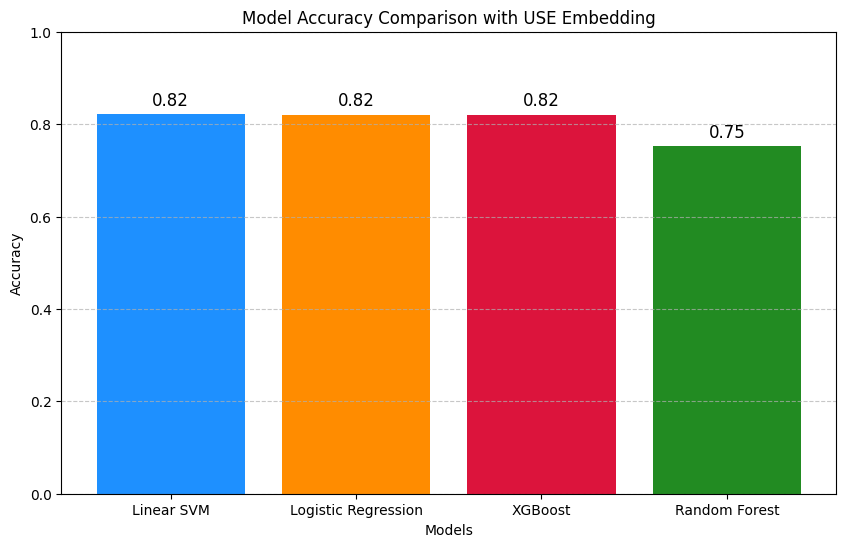

In [164]:
# List model names dan akurasi sesuai hasil evaluasi sebelumnya
model_names = ['Linear SVM', 'Logistic Regression', 'XGBoost', 'Random Forest']
model_accuracies = [accuracy_svm_use, accuracy_lr_use, accuracy_xgboost_use, accuracy_rfc_use]

# Membuat plot perbandingan akurasi model
plt.figure(figsize=(10, 6))
plt.bar(model_names, model_accuracies, color=['dodgerblue', 'darkorange', 'crimson', 'forestgreen'])
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison with USE Embedding")
plt.ylim(0.0, 1.0)  # Set batas y-axis dari 0 hingga 1
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Menampilkan nilai akurasi pada setiap batang
for i, acc in enumerate(model_accuracies):
    plt.text(i, acc + 0.02, f"{acc:.2f}", ha='center', color='black', fontsize=12)

plt.show()


# TF-IDF + Universal Sentence Encoder (USE)
1. Linear SVM
2. Logistic Regression
3. XGBoost classifier
4. Random Forest classifier

## Combine TF-IDF and Universal Sentence Encoder embeddings

In [165]:
# Menggabungkan TF-IDF dan USE untuk data training dan testing
xtrain_tfidf_use_combined = np.concatenate((tfidf_vectorizer_xtrain, xtrain_use), axis=1)
xtest_tfidf_use_combined = np.concatenate((tfidf_vectorizer_xtest, xtest_use), axis=1)


## Fit classifiers

In [166]:
# Training Linear SVM dengan fitur gabungan (TF-IDF + USE)
start = timer()
svm_tfidf_use = svm_classifier.fit(xtrain_tfidf_use_combined, ytrain)
print('Required time for training Linear SVM (TF-IDF + USE):', timer() - start)

# Training Logistic Regression dengan fitur gabungan (TF-IDF + USE)
start = timer()
lr_tfidf_use = logistic_regression.fit(xtrain_tfidf_use_combined, ytrain)
print('Required time for training Logistic Regression (TF-IDF + USE):', timer() - start)

# Training XGBoost dengan fitur gabungan (TF-IDF + USE)
start = timer()
xgboost_tfidf_use = xgboost_classifier.fit(xtrain_tfidf_use_combined, ytrain)
print('Required time for training XGBoost classifier (TF-IDF + USE):', timer() - start)

# Training Random Forest dengan fitur gabungan (TF-IDF + USE)
start = timer()
rfc_tfidf_use = random_forest_classifier.fit(xtrain_tfidf_use_combined, ytrain)
print('Required time for training Random Forest classifier (TF-IDF + USE):', timer() - start)


Required time for training Linear SVM (TF-IDF + USE): 347.8874141000015
Required time for training Logistic Regression (TF-IDF + USE): 197.86378219999824
Required time for training XGBoost classifier (TF-IDF + USE): 1403.411027099999
Required time for training Random Forest classifier (TF-IDF + USE): 106.16031990000192


## Linear SVM 

In [167]:
start = timer()
y_pred_svm_tfidf_use, accuracy_svm_tfidf_use, precision_svm_tfidf_use, recall_svm_tfidf_use, f1_svm_tfidf_use, report_svm_tfidf_use, cm_svm_tfidf_use = evaluate_model(svm_tfidf_use, xtest_tfidf_use_combined, ytest)
print('Required time for Linear SVM prediction with TF-IDF + USE:', timer() - start)

Required time for Linear SVM prediction with TF-IDF + USE: 2.9926887000001443


### Print actual vs. predicted results for Linear SVM with TFIDF + USE

In [168]:
print("Label: 0 = Negatif, 1 = Netral, 2 = Positif")
print("=== Hasil Prediksi Linear SVM dengan TF-IDF + USE Embedding (Multiple Class) ===")
for actual, predicted in zip(ytest[:15], y_pred_svm_tfidf_use[:15]):
    print(f"Actual: {actual}, Linear SVM (TF-IDF + USE) Predicted: {predicted}")
print()

Label: 0 = Negatif, 1 = Netral, 2 = Positif
=== Hasil Prediksi Linear SVM dengan TF-IDF + USE Embedding (Multiple Class) ===
Actual: 0, Linear SVM (TF-IDF + USE) Predicted: 2
Actual: 2, Linear SVM (TF-IDF + USE) Predicted: 2
Actual: 2, Linear SVM (TF-IDF + USE) Predicted: 2
Actual: 2, Linear SVM (TF-IDF + USE) Predicted: 2
Actual: 2, Linear SVM (TF-IDF + USE) Predicted: 2
Actual: 0, Linear SVM (TF-IDF + USE) Predicted: 0
Actual: 2, Linear SVM (TF-IDF + USE) Predicted: 2
Actual: 2, Linear SVM (TF-IDF + USE) Predicted: 2
Actual: 2, Linear SVM (TF-IDF + USE) Predicted: 2
Actual: 0, Linear SVM (TF-IDF + USE) Predicted: 0
Actual: 2, Linear SVM (TF-IDF + USE) Predicted: 2
Actual: 2, Linear SVM (TF-IDF + USE) Predicted: 2
Actual: 2, Linear SVM (TF-IDF + USE) Predicted: 2
Actual: 2, Linear SVM (TF-IDF + USE) Predicted: 2
Actual: 2, Linear SVM (TF-IDF + USE) Predicted: 2



In [169]:
print(f"Linear SVM (TF-IDF + USE) Accuracy: {accuracy_svm_tfidf_use:.2f}")
print(f"Linear SVM (TF-IDF + USE) Precision: {precision_svm_tfidf_use:.2f}")
print(f"Linear SVM (TF-IDF + USE) Recall: {recall_svm_tfidf_use:.2f}")
print(f"Linear SVM (TF-IDF + USE) F1 score: {f1_svm_tfidf_use:.2f}")
print("Classification Report:")
print(report_svm_tfidf_use)
print("Confusion Matrix:")
print(cm_svm_tfidf_use)

Linear SVM (TF-IDF + USE) Accuracy: 0.84
Linear SVM (TF-IDF + USE) Precision: 0.81
Linear SVM (TF-IDF + USE) Recall: 0.84
Linear SVM (TF-IDF + USE) F1 score: 0.82
Classification Report:
              precision    recall  f1-score   support

    Negative       0.70      0.78      0.74      4124
     Neutral       0.32      0.07      0.12      1794
    Positive       0.89      0.95      0.92     14728

    accuracy                           0.84     20646
   macro avg       0.64      0.60      0.59     20646
weighted avg       0.81      0.84      0.82     20646

Confusion Matrix:
[[ 3230   135   759]
 [  765   132   897]
 [  608   144 13976]]


## Logistic Regression

In [ ]:
start = timer()
y_pred_lr_tfidf_use, accuracy_lr_tfidf_use, precision_lr_tfidf_use, recall_lr_tfidf_use, f1_lr_tfidf_use, report_lr_tfidf_use, cm_lr_tfidf_use = evaluate_model(lr_tfidf_use, xtest_tfidf_use_combined, ytest)
print('Required time for Logistic Regression prediction with TF-IDF + USE:', timer() - start)

Required time for Logistic Regression prediction with TF-IDF + USE: 0.41989050000120187


### Print actual vs. predicted results for Logistic Regression with TFIDF + USE

In [170]:
# Menampilkan label untuk multiple class
print("Label: 0 = Negatif, 1 = Netral, 2 = Positif")

# Menampilkan hasil prediksi untuk 15 data pertama
print("=== Hasil Prediksi Logistic Regression dengan TF-IDF + USE Embedding (Multiple Class) ===")
label_dict = {0: 'Negatif', 1: 'Netral', 2: 'Positif'}  # Menggunakan dictionary untuk label
for actual, predicted in zip(ytest[:15], y_pred_lr_tfidf_use[:15]):
    # Menampilkan hasil prediksi dan label sebenarnya
    print(f"Actual: {actual} ({label_dict[actual]}), Logistic Regression (TF-IDF + USE) Predicted: {predicted} ({label_dict[predicted]})")
    print()

Label: 0 = Negatif, 1 = Netral, 2 = Positif
=== Hasil Prediksi Logistic Regression dengan TF-IDF + USE Embedding (Multiple Class) ===
Actual: 0 (Negatif), Logistic Regression (TF-IDF + USE) Predicted: 2 (Positif)

Actual: 2 (Positif), Logistic Regression (TF-IDF + USE) Predicted: 2 (Positif)

Actual: 2 (Positif), Logistic Regression (TF-IDF + USE) Predicted: 2 (Positif)

Actual: 2 (Positif), Logistic Regression (TF-IDF + USE) Predicted: 2 (Positif)

Actual: 2 (Positif), Logistic Regression (TF-IDF + USE) Predicted: 2 (Positif)

Actual: 0 (Negatif), Logistic Regression (TF-IDF + USE) Predicted: 0 (Negatif)

Actual: 2 (Positif), Logistic Regression (TF-IDF + USE) Predicted: 2 (Positif)

Actual: 2 (Positif), Logistic Regression (TF-IDF + USE) Predicted: 2 (Positif)

Actual: 2 (Positif), Logistic Regression (TF-IDF + USE) Predicted: 2 (Positif)

Actual: 0 (Negatif), Logistic Regression (TF-IDF + USE) Predicted: 0 (Negatif)

Actual: 2 (Positif), Logistic Regression (TF-IDF + USE) Predicted:

In [171]:
print(f"Logistic Regression (TF-IDF + USE) Accuracy: {accuracy_lr_tfidf_use:.2f}")
print(f"Logistic Regression (TF-IDF + USE) Precision: {precision_lr_tfidf_use:.2f}")
print(f"Logistic Regression (TF-IDF + USE) Recall: {recall_lr_tfidf_use:.2f}")
print(f"Logistic Regression (TF-IDF + USE) F1 score: {f1_lr_tfidf_use:.2f}")
print("Classification Report:")
print(report_lr_tfidf_use)
print("Confusion Matrix:")
print(cm_lr_tfidf_use)

Logistic Regression (TF-IDF + USE) Accuracy: 0.84
Logistic Regression (TF-IDF + USE) Precision: 0.81
Logistic Regression (TF-IDF + USE) Recall: 0.84
Logistic Regression (TF-IDF + USE) F1 score: 0.82
Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.79      0.74      4124
           1       0.33      0.09      0.15      1794
           2       0.90      0.95      0.92     14728

    accuracy                           0.84     20646
   macro avg       0.65      0.61      0.60     20646
weighted avg       0.81      0.84      0.82     20646

Confusion Matrix:
[[ 3240   159   725]
 [  752   168   874]
 [  583   176 13969]]


## XGBoost Classifier

In [172]:
start = timer()
y_pred_xgb_tfidf_use, accuracy_xgb_tfidf_use, precision_xgb_tfidf_use, recall_xgb_tfidf_use, f1_xgb_tfidf_use, report_xgb_tfidf_use, cm_xgb_tfidf_use = evaluate_model(xgboost_tfidf_use, xtest_tfidf_use_combined, ytest)
print('Required time for XGBoost prediction with TF-IDF + USE:', timer() - start)

Required time for XGBoost prediction with TF-IDF + USE: 0.6341585000009218


### Print actual vs. predicted results for XGBoost with TFIDF + USE

In [173]:
# Menampilkan label untuk multiple class
print("Label: 0 = Negatif, 1 = Netral, 2 = Positif")

# Menampilkan hasil prediksi untuk 15 data pertama
print("=== Hasil Prediksi XGBoost dengan TF-IDF + USE Embedding (Multiple Class) ===")
label_dict = {0: 'Negatif', 1: 'Netral', 2: 'Positif'}  # Menggunakan dictionary untuk label
for actual, predicted in zip(ytest[:15], y_pred_xgb_tfidf_use[:15]):
    # Menampilkan hasil prediksi dan label sebenarnya
    print(f"Actual: {actual} ({label_dict[actual]}), XGBoost (TF-IDF + USE) Predicted: {predicted} ({label_dict[predicted]})")
    print()

Label: 0 = Negatif, 1 = Netral, 2 = Positif
=== Hasil Prediksi XGBoost dengan TF-IDF + USE Embedding (Multiple Class) ===
Actual: 0 (Negatif), XGBoost (TF-IDF + USE) Predicted: 2 (Positif)

Actual: 2 (Positif), XGBoost (TF-IDF + USE) Predicted: 2 (Positif)

Actual: 2 (Positif), XGBoost (TF-IDF + USE) Predicted: 2 (Positif)

Actual: 2 (Positif), XGBoost (TF-IDF + USE) Predicted: 2 (Positif)

Actual: 2 (Positif), XGBoost (TF-IDF + USE) Predicted: 2 (Positif)

Actual: 0 (Negatif), XGBoost (TF-IDF + USE) Predicted: 0 (Negatif)

Actual: 2 (Positif), XGBoost (TF-IDF + USE) Predicted: 2 (Positif)

Actual: 2 (Positif), XGBoost (TF-IDF + USE) Predicted: 2 (Positif)

Actual: 2 (Positif), XGBoost (TF-IDF + USE) Predicted: 2 (Positif)

Actual: 0 (Negatif), XGBoost (TF-IDF + USE) Predicted: 0 (Negatif)

Actual: 2 (Positif), XGBoost (TF-IDF + USE) Predicted: 2 (Positif)

Actual: 2 (Positif), XGBoost (TF-IDF + USE) Predicted: 2 (Positif)

Actual: 2 (Positif), XGBoost (TF-IDF + USE) Predicted: 2 (Posi

In [174]:
# Menampilkan metrik evaluasi
print(f"XGBoost (TF-IDF + USE) Accuracy: {accuracy_xgb_tfidf_use:.2f}")
print(f"XGBoost (TF-IDF + USE) Precision: {precision_xgb_tfidf_use:.2f}")
print(f"XGBoost (TF-IDF + USE) Recall: {recall_xgb_tfidf_use:.2f}")
print(f"XGBoost (TF-IDF + USE) F1 score: {f1_xgb_tfidf_use:.2f}")
print("Classification Report:")
print(report_xgb_tfidf_use)
print("Confusion Matrix:")
print(cm_xgb_tfidf_use)

XGBoost (TF-IDF + USE) Accuracy: 0.83
XGBoost (TF-IDF + USE) Precision: 0.79
XGBoost (TF-IDF + USE) Recall: 0.83
XGBoost (TF-IDF + USE) F1 score: 0.80
Classification Report:
              precision    recall  f1-score   support

    Negative       0.68      0.76      0.72      4124
     Neutral       0.26      0.04      0.07      1794
    Positive       0.89      0.94      0.91     14728

    accuracy                           0.83     20646
   macro avg       0.61      0.58      0.57     20646
weighted avg       0.79      0.83      0.80     20646

Confusion Matrix:
[[ 3152   103   869]
 [  804    75   915]
 [  704   115 13909]]


## Random Forest classifier

In [175]:
start = timer()
y_pred_rfc_tfidf_use, accuracy_rfc_tfidf_use, precision_rfc_tfidf_use, recall_rfc_tfidf_use, f1_rfc_tfidf_use, report_rfc_tfidf_use, cm_rfc_tfidf_use = evaluate_model(rfc_tfidf_use, xtest_tfidf_use_combined, ytest)
print('Required time for Random Forest prediction with TF-IDF + USE:', timer() - start)

Required time for Random Forest prediction with TF-IDF + USE: 1.631080799998017


d:\Rani\NLP (B) 2025\SentimentAnalysis\env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Rani\NLP (B) 2025\SentimentAnalysis\env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Rani\NLP (B) 2025\SentimentAnalysis\env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

### Print actual vs. predicted results for Random Forest with TFIDF + USE

In [176]:
# Menampilkan label untuk multiple class
print("Label: 0 = Negatif, 1 = Netral, 2 = Positif")

# Menampilkan hasil prediksi untuk 15 data pertama
print("=== Hasil Prediksi Random Forest dengan TF-IDF + USE Embedding (Multiple Class) ===")
label_dict = {0: 'Negatif', 1: 'Netral', 2: 'Positif'}  # Menggunakan dictionary untuk label
for actual, predicted in zip(ytest[:15], y_pred_rfc_tfidf_use[:15]):
    # Menampilkan hasil prediksi dan label sebenarnya
    print(f"Actual: {actual} ({label_dict[actual]}), Random Forest (TF-IDF + USE) Predicted: {predicted} ({label_dict[predicted]})")
    print()


Label: 0 = Negatif, 1 = Netral, 2 = Positif
=== Hasil Prediksi Random Forest dengan TF-IDF + USE Embedding (Multiple Class) ===
Actual: 0 (Negatif), Random Forest (TF-IDF + USE) Predicted: 2 (Positif)

Actual: 2 (Positif), Random Forest (TF-IDF + USE) Predicted: 2 (Positif)

Actual: 2 (Positif), Random Forest (TF-IDF + USE) Predicted: 2 (Positif)

Actual: 2 (Positif), Random Forest (TF-IDF + USE) Predicted: 2 (Positif)

Actual: 2 (Positif), Random Forest (TF-IDF + USE) Predicted: 2 (Positif)

Actual: 0 (Negatif), Random Forest (TF-IDF + USE) Predicted: 2 (Positif)

Actual: 2 (Positif), Random Forest (TF-IDF + USE) Predicted: 2 (Positif)

Actual: 2 (Positif), Random Forest (TF-IDF + USE) Predicted: 2 (Positif)

Actual: 2 (Positif), Random Forest (TF-IDF + USE) Predicted: 2 (Positif)

Actual: 0 (Negatif), Random Forest (TF-IDF + USE) Predicted: 2 (Positif)

Actual: 2 (Positif), Random Forest (TF-IDF + USE) Predicted: 2 (Positif)

Actual: 2 (Positif), Random Forest (TF-IDF + USE) Predicte

In [177]:
# Menampilkan metrik evaluasi
print(f"Random Forest (TF-IDF + USE) Accuracy: {accuracy_rfc_tfidf_use:.2f}")
print(f"Random Forest (TF-IDF + USE) Precision: {precision_rfc_tfidf_use:.2f}")
print(f"Random Forest (TF-IDF + USE) Recall: {recall_rfc_tfidf_use:.2f}")
print(f"Random Forest (TF-IDF + USE) F1 score: {f1_rfc_tfidf_use:.2f}")
print("\nClassification Report:")
print(report_rfc_tfidf_use)
print("\nConfusion Matrix:")
print(cm_rfc_tfidf_use)

Random Forest (TF-IDF + USE) Accuracy: 0.71
Random Forest (TF-IDF + USE) Precision: 0.70
Random Forest (TF-IDF + USE) Recall: 0.71
Random Forest (TF-IDF + USE) F1 score: 0.60

Classification Report:
              precision    recall  f1-score   support

    Negative       0.94      0.01      0.02      4124
     Neutral       0.00      0.00      0.00      1794
    Positive       0.71      1.00      0.83     14728

    accuracy                           0.71     20646
   macro avg       0.55      0.34      0.28     20646
weighted avg       0.70      0.71      0.60     20646


Confusion Matrix:
[[   33     0  4091]
 [    2     0  1792]
 [    0     0 14728]]


## Display all four models accuracy

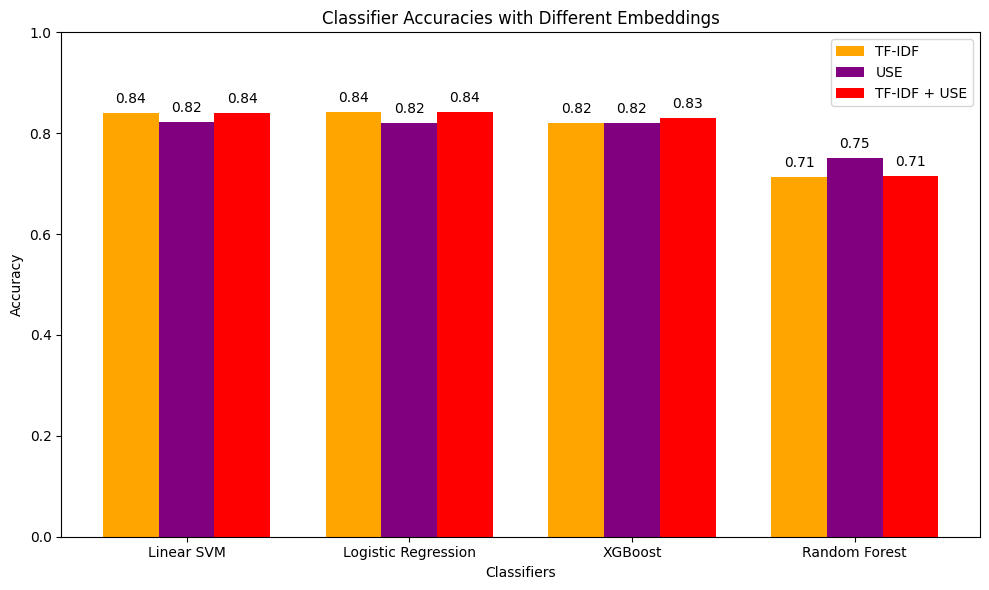

In [180]:
# Define the classifiers and their corresponding accuracies
classifiers = ['Linear SVM', 'Logistic Regression', 'XGBoost', 'Random Forest']
tfidf_accuracies = [accuracy_svm, accuracy_lr, accuracy_xgboost, accuracy_rfc]  # Replace with actual accuracy values
use_accuracies = [accuracy_svm_use, accuracy_lr_use, accuracy_xgboost_use, accuracy_rfc_use]  # Replace with actual accuracy values
tfidf_use_accuracies = [accuracy_svm_tfidf_use, accuracy_lr_tfidf_use, accuracy_xgb_tfidf_use, accuracy_rfc_tfidf_use]  # Replace with actual accuracy values

# Create an index for the x-axis
x = np.arange(len(classifiers))

# Set the width of the bars
bar_width = 0.25

# Create a grouped bar chart
plt.figure(figsize=(10, 6))
plt.bar(x - bar_width, tfidf_accuracies, bar_width, label='TF-IDF', color='orange')
plt.bar(x, use_accuracies, bar_width, label='USE', color='purple')
plt.bar(x + bar_width, tfidf_use_accuracies, bar_width, label='TF-IDF + USE', color='red')

# Set labels, title, and legend
plt.xlabel('Classifiers')
plt.ylabel('Accuracy')
plt.title('Classifier Accuracies with Different Embeddings')
plt.xticks(x, classifiers)
plt.ylim(0, 1.0)
plt.legend()

# Add accuracy values on top of the bars
for i in range(len(classifiers)):
    plt.text(x[i] - bar_width, tfidf_accuracies[i] + 0.02, f"{tfidf_accuracies[i]:.2f}", ha='center')
    plt.text(x[i], use_accuracies[i] + 0.02, f"{use_accuracies[i]:.2f}", ha='center')
    plt.text(x[i] + bar_width, tfidf_use_accuracies[i] + 0.02, f"{tfidf_use_accuracies[i]:.2f}", ha='center')

# Display the plot
plt.tight_layout()
plt.show()


Kesimpulan :

Grafik ini menunjukkan bagaimana pemilihan metode embedding teks mempengaruhi akurasi berbagai model klasifikasi. Secara umum, kombinasi TF-IDF + USE memberikan hasil terbaik atau setidaknya setara dengan TF-IDF saja, menunjukkan bahwa menggabungkan fitur berbasis kata dan pemahaman konteks kalimat dapat meningkatkan performa model. Linear SVM dan Logistic Regression bekerja sangat baik dengan TF-IDF dan kombinasi TF-IDF + USE, mencapai akurasi 0.84, sementara penggunaan USE saja sedikit menurunkan akurasi menjadi 0.82. XGBoost juga menunjukkan tren serupa, dengan akurasi tertinggi (0.83) saat menggunakan kombinasi embedding.

Sebaliknya, Random Forest memiliki performa yang kurang optimal untuk klasifikasi teks, dengan akurasi terbaiknya hanya 0.75 saat menggunakan USE, sementara metode lainnya hanya mencapai 0.71. Ini menunjukkan bahwa metode berbasis pohon keputusan mungkin kurang efektif dalam menangani data teks dibandingkan dengan model berbasis vektor seperti SVM dan regresi logistik.